In [1]:
print("Hello, World!")

Hello, World!


n_neighbors: 3일때 정확도: 0.960


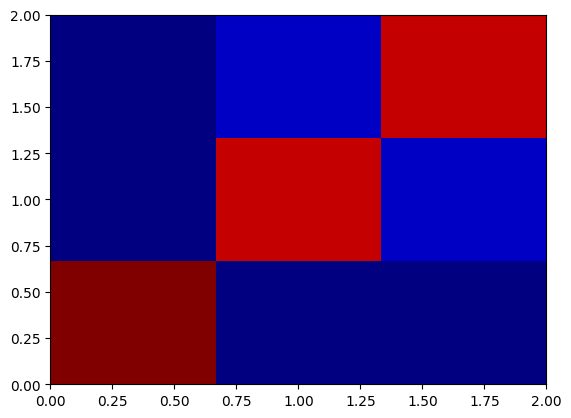

[[50  0  0]
 [ 0 47  3]
 [ 0  3 47]]


In [ ]:
from sklearn import metrics

from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier

iris = load_iris()
k = 3
knn = KNeighborsClassifier(n_neighbors=k)

# 거리 계산을 하는 것인데 fitting이 필요한가?
knn.fit(iris.data, iris.target) 
y_pred_all = knn.predict(iris.data)
scores = metrics.accuracy_score(iris.target, y_pred_all)
print('n_neighbors: {0:d}일때 정확도: {1:.3f}'.format(k, scores))

import matplotlib.pyplot as plt
plt.hist2d(iris.target, y_pred_all, bins=(3, 3), cmap=plt.cm.jet)
plt.show()

from sklearn.metrics import confusion_matrix
conf_mat = confusion_matrix(iris.target, y_pred_all)
print(conf_mat)
# class 2, 3에서는 구분하기가 좀 어렵다.


In [8]:
import numpy as np

target = np.array([0] * 10 + [1] * 10)
print(target)

pred = np.array([0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1])
print(pred)

from sklearn.metrics import confusion_matrix
confusion_matrix(target, pred)

[0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1]
[0 0 0 0 0 1 1 1 0 0 1 1 1 1 1 1 0 0 1 1]


array([[7, 3],
       [2, 8]])

In [11]:
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score
print('정밀도 :', precision_score(target, pred))
print('재현율 :', recall_score(target, pred))

print('정확도 :', accuracy_score(target, pred))
print('F1 점수 :', f1_score(target, pred))


정밀도 : 0.7272727272727273
재현율 : 0.8
정확도 : 0.75
F1 점수 : 0.7619047619047619


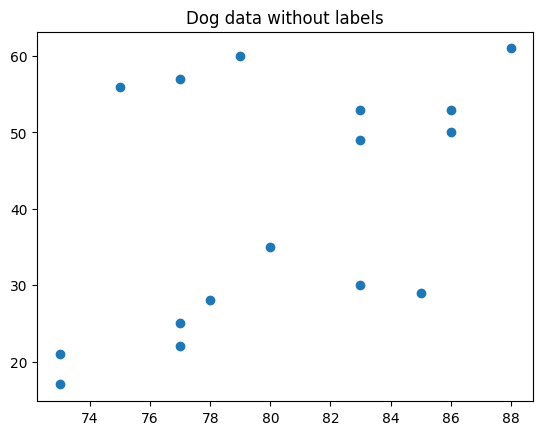

In [13]:
import numpy as np
import matplotlib.pyplot as plt

dach_length = [77, 78, 85, 83, 73, 77, 73, 80]
dach_height = [25, 28, 29, 30, 21, 22, 17, 35]

samo_length = [75, 77, 86, 86, 79, 83, 83, 88]
samo_hight = [56, 57, 50, 53, 60, 53, 49, 61]

newdata_length = [82]
newdata_height = [40]


dog_length = np.array(dach_length + samo_length)
dog_height = np.array(dach_height + samo_hight)

dog_data = np.column_stack((dog_length, dog_height))

plt.title('Dog data without labels')
plt.scatter(dog_length, dog_height)


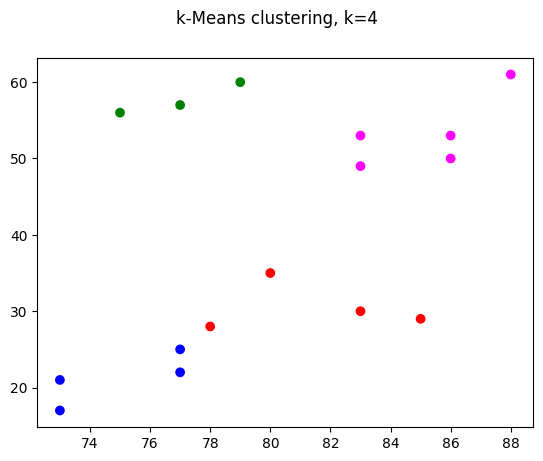

In [33]:
from sklearn import cluster

dach_length = [77, 78, 85, 83, 73, 77, 73, 80]
dach_height = [25, 28, 29, 30, 21, 22, 17, 35]

samo_length = [75, 77, 86, 86, 79, 83, 83, 88]
samo_hight = [56, 57, 50, 53, 60, 53, 49, 61]

newdata_length = [82]
newdata_height = [40]

dog_length = np.array(dach_length + samo_length)
dog_height = np.array(dach_height + samo_hight)

dog_data = np.column_stack((dog_length, dog_height))


def kmeans_predict_plot(x, k):
    model = cluster.KMeans(n_clusters=k)
    model.fit(x)
    labels = model.predict(x)
    colors = np.array(['red', 'green', 'blue', 'magenta'])
    plt.suptitle('k-Means clustering, k={}'.format(k))
    plt.scatter(x[:, 0], x[:, 1], c=colors[labels])

# kmeans_predict_plot(dog_data, k=2)
# kmeans_predict_plot(dog_data, k=3)
kmeans_predict_plot(dog_data, k=4)

kMeans() 군집화 적용...
군집화 결과 labels = [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 2 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 2 2 2 2 0 2 2 2 2
 2 2 0 0 2 2 2 2 0 2 0 2 0 2 2 0 0 2 2 2 2 2 0 2 2 2 2 0 2 2 2 0 2 2 2 0 2
 2 0]
다시 레이블링을 한 후의 new_labels = [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 2 1 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 1 2 2 2 2 1 2 2 2 2
 2 2 1 1 2 2 2 2 1 2 1 2 1 2 2 1 1 2 2 2 2 2 1 2 2 2 2 1 2 2 2 1 2 2 2 1 2
 2 1]
iris 데이터의 군집화 정확도: 0.8866666666666667


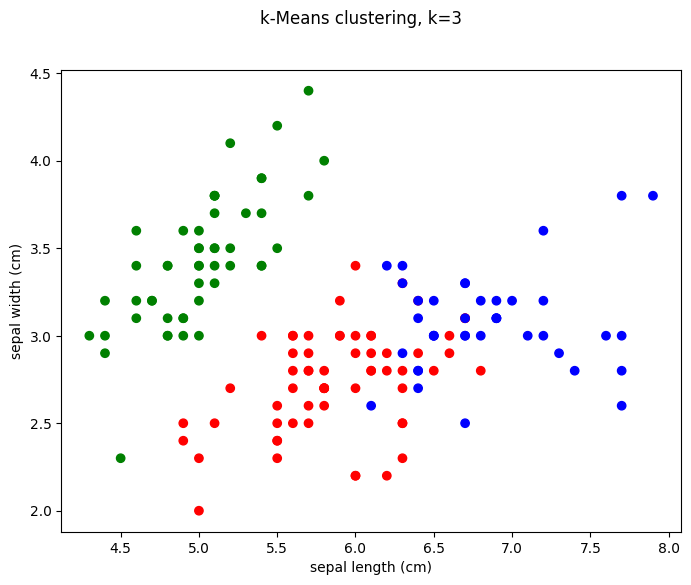

In [42]:
from sklearn import datasets, cluster
from sklearn.metrics import accuracy_score
import numpy as np
from scipy.stats import mode

# 비지도 학습이므로 타겟값은 사용하지 않음(정답을 모르는 상태에서 데이터를 끼리끼리 묶은 뒤 )



# data set 불러옴
iris = datasets.load_iris()
x = iris.data
y = iris.target

# k-Means 모델 구성 및 예측
model = cluster.KMeans(n_clusters=3)
model.fit(x)
labels = model.predict(x)

print("kMeans() 군집화 적용...")
print(f"군집화 결과 labels = {labels}")

# 2. 라벨링
new_labels = np.zeros_like(labels)
for i in range(k):
    mask = (labels == i)
    # 최빈 타겟값을 새 라벨로 지정
    new_labels[mask] = mode(y[mask])[0]

print(f"다시 레이블링을 한 후의 new_labels = {new_labels}")

# 정확도 출력
accuracy = accuracy_score(y, new_labels)
print(f"iris 데이터의 군집화 정확도: {accuracy}")


# 추가: 시각화
colors = np.array(['red', 'green', 'blue'])
plt.figure(figsize=(8, 6))
plt.suptitle('k-Means clustering, k={}'.format(k))

# x[:, 0]은 꽃받침 길이, x[:, 1]은 꽃받침 너비
plt.scatter(x[:, 0], x[:, 1], c=colors[labels]) 
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.show()